# What is driving the fall in A&E performance in Scotland?

Between 2015 and 2019 roughly 90% of patients at Scotland's major Emergency Departments were seen
within 4 hours. Today it is around 63%, against a 95% target. This notebook tests three candidate
explanations using Public Health Scotland open data:

1. **Demand**: more people are attending A&E.
2. **Delayed discharges**: patients medically ready to leave hospital cannot, so beds are blocked
   and A&E patients wait for a ward.
3. **Bed occupancy**: hospitals are simply too full.

Data comes from the DuckDB warehouse built by `src/pipeline.py`; the analysis functions live in
`src/analysis.py` so the dashboard reports identical numbers.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import analysis

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
FIGURES = Path.cwd().parent / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
pd.options.display.float_format = "{:.1f}".format

## 1. When did performance break?

Rather than assume COVID was the turning point, I let the data choose. The function below tries
every possible week as a split point and picks the one where two flat averages (before and after)
fit the series best, i.e. the lowest total squared error.

Break point: week ending 08 August 2021
Mean before: 90.4%   Mean after: 66.1%


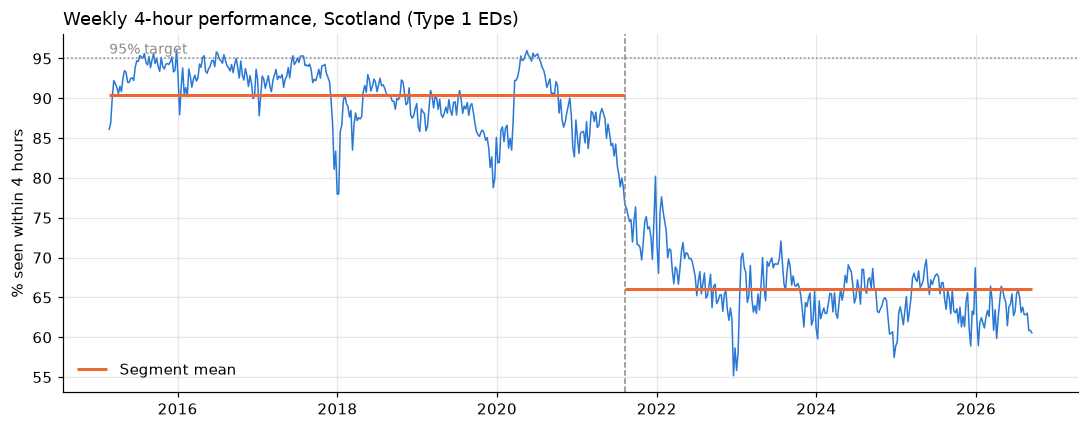

In [2]:
weekly = analysis.query("SELECT week_ending, pct_within_4h, attendances FROM mart_weekly_national")
weekly = weekly.set_index("week_ending")
brk = analysis.find_break(weekly["pct_within_4h"])
print(f"Break point: week ending {brk['date']:%d %B %Y}")
print(f"Mean before: {brk['mean_before']:.1f}%   Mean after: {brk['mean_after']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly.index, weekly["pct_within_4h"], color=BLUE, lw=1)
ax.axvline(brk["date"], color=GREY, ls="--", lw=1)
ax.hlines(brk["mean_before"], weekly.index.min(), brk["date"], color=ORANGE, lw=2)
ax.hlines(brk["mean_after"], brk["date"], weekly.index.max(), color=ORANGE, lw=2, label="Segment mean")
ax.axhline(95, color=GREY, lw=1, ls=":")
ax.text(weekly.index.min(), 95.6, "95% target", color=GREY, fontsize=9)
ax.set_ylabel("% seen within 4 hours")
ax.set_title("Weekly 4-hour performance, Scotland (Type 1 EDs)", loc="left")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES / "break_point.png")

The break lands in **August 2021**, not March 2020. Performance actually *improved* during the
first lockdown (attendances collapsed) and fell away as activity returned in 2021. Since then it
has settled around a new, much lower level and has not recovered.

## 2. Is it demand?

If more people were attending, we would expect attendances to have risen alongside the decline.

In [3]:
yearly = weekly.assign(year=weekly.index.year).groupby("year").agg(
    attendances=("attendances", "sum"), weeks=("attendances", "size"))
yearly["attendances_per_week"] = yearly["attendances"] / yearly["weeks"]
yearly[["attendances_per_week"]].T

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
attendances_per_week,25139.9,25630.4,25910.5,26306.8,27625.3,20907.8,23909.9,25707.8,25626.5,26856.5,27031.0,28139.9


Spearman rank correlation: 0.49


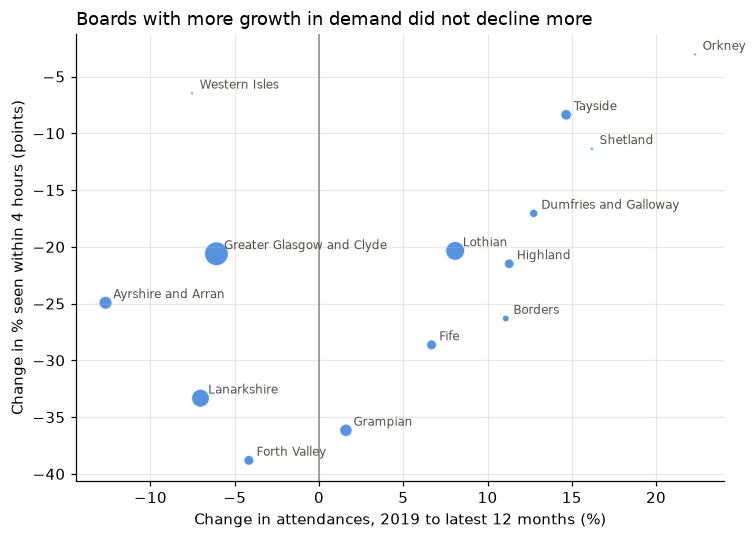

In [4]:
changes = analysis.board_change(base_year=2019)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(changes["attendance_change_pct"], changes["change_pts"], s=changes["attendances_base"] / 1500,
           color=BLUE, alpha=0.8, edgecolor="white")
for name, r in changes.iterrows():
    ax.annotate(name.replace("NHS ", ""), (r["attendance_change_pct"], r["change_pts"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points", color="#52514e")
ax.axvline(0, color=GREY, lw=1)
ax.set_xlabel("Change in attendances, 2019 to latest 12 months (%)")
ax.set_ylabel("Change in % seen within 4 hours (points)")
ax.set_title("Boards with more growth in demand did not decline more", loc="left")
fig.tight_layout()
fig.savefig(FIGURES / "demand_vs_performance.png")

rho = changes[["attendance_change_pct", "change_pts"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman rank correlation: {rho:.2f}")

The weekly attendances are similar to 2019 levels, while across the 14 health boards the relationship between demand and waiting times was the opposite of the hypothesis. The boards where attendances grew the most were mainly the smaller, more rural boards, and they declined the least in terms of the % seen within 4 hours, showing that demand does not explain the increase in waiting times.

I use Spearman's rank correlation rather than Pearson's here because there are only 14 boards and
a few extreme values (e.g. Orkney) would otherwise dominate.

## 3. Is it delayed discharges?

At national level, delayed discharges and A&E performance do move together. The two measures are
on different scales, so they are shown as separate panels sharing a time axis rather than on a
dual-axis chart.

Correlation (national, monthly): -0.87


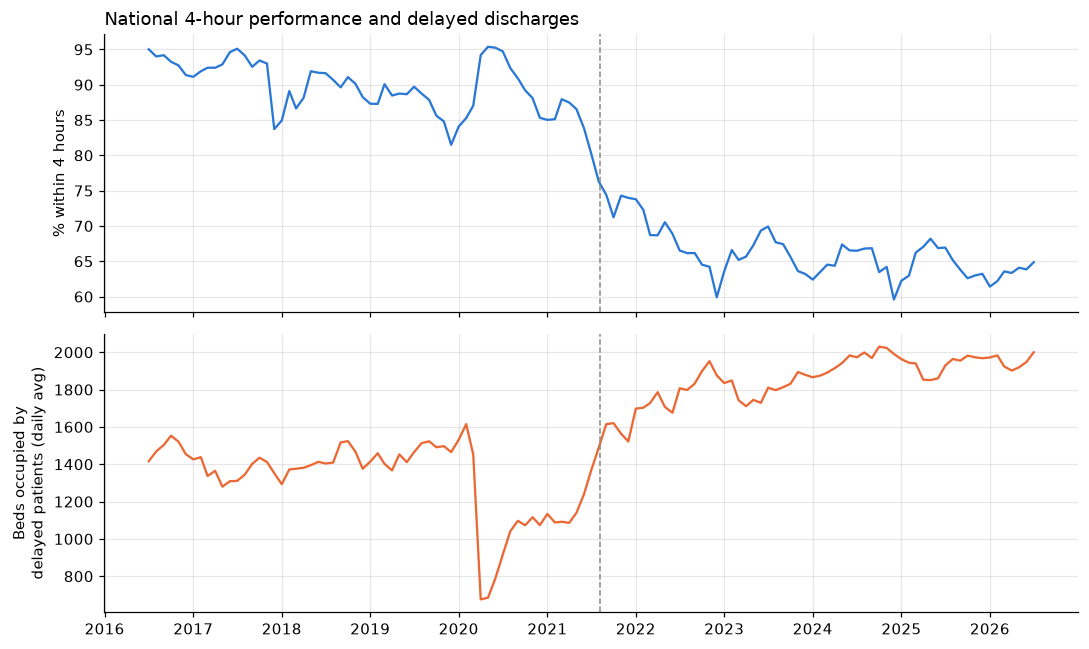

In [5]:
monthly = analysis.query("SELECT * FROM mart_monthly_board_drivers")
nat = monthly.groupby("month").apply(lambda d: pd.Series({
    "delayed_beds": d["avg_daily_delayed_beds"].sum(),
    "pct_within_4h": (d["pct_within_4h"] * d["attendances"]).sum() / d["attendances"].sum(),
}), include_groups=False)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
top.plot(nat.index, nat["pct_within_4h"], color=BLUE, lw=1.5)
top.set_ylabel("% within 4 hours")
top.set_title("National 4-hour performance and delayed discharges", loc="left")
bottom.plot(nat.index, nat["delayed_beds"], color=ORANGE, lw=1.5)
bottom.set_ylabel("Beds occupied by\ndelayed patients (daily avg)")
for a in (top, bottom):
    a.axvline(brk["date"], color=GREY, ls="--", lw=1)
fig.tight_layout()
fig.savefig(FIGURES / "delays_national.png")

print(f"Correlation (national, monthly): {nat.corr().iloc[0, 1]:.2f}")

The spring 2020 lockdown is a useful natural experiment: delayed discharges fell by more than half
in weeks and A&E performance briefly returned to the 95% target. Both then deteriorated together
through 2021.

A strong national correlation is not enough on its own, though: anything else that worsened after 2021
(staffing, the acuity of patients, the aftermath of COVID) would produce the same picture. The
board-level data lets me separate these.

**Model A** compares each board with itself over time (board fixed effects). This still carries
the national trend, so it mostly repeats the chart above.

**Model B** adds a fixed effect for every month. That absorbs anything that hit *all* boards at
the same time, so the only question left is: *did boards whose delays rose more than other boards
also decline more than other boards?*

Both models control for attendances. Delays and attendances enter as logs so the coefficients read
as the effect of a 10% rise. Standard errors are clustered by board, because consecutive months
from the same board are not independent observations.

In [6]:
models = analysis.panel_models()
models.style.format({"effect_of_10pct_rise_pts": "{:+.2f}", "p_value": "{:.3f}", "r_squared": "{:.2f}"}).hide(axis="index")

model,variable,effect_of_10pct_rise_pts,p_value,r_squared,n
A: board effects,Delayed discharges,-0.96,0.010,0.45,1694
A: board effects,Attendances,-0.23,0.540,0.45,1694
B: board + month effects,Delayed discharges,+0.21,0.208,0.85,1694
B: board + month effects,Attendances,+2.12,0.041,0.85,1694


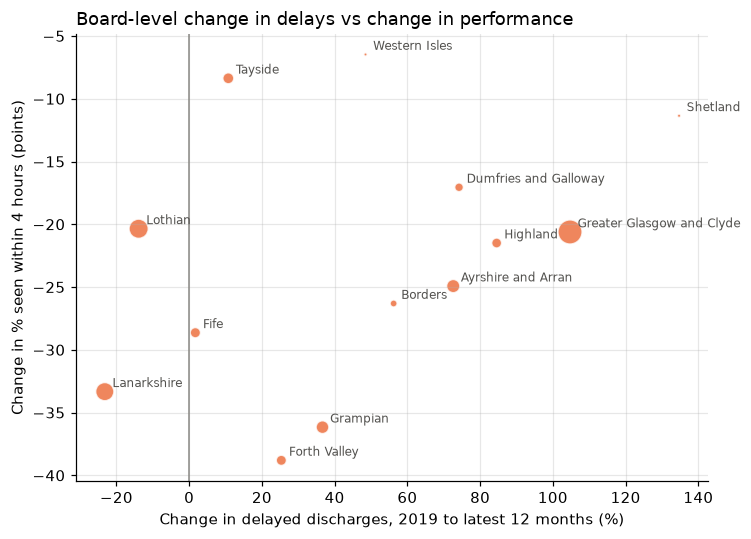

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
plot = changes.drop(index="NHS Orkney")  # delays rose from 1 to 13 beds: +1,233%, off the scale
ax.scatter(plot["delayed_change_pct"], plot["change_pts"], s=plot["attendances_base"] / 1500,
           color=ORANGE, alpha=0.8, edgecolor="white")
for name, r in plot.iterrows():
    ax.annotate(name.replace("NHS ", ""), (r["delayed_change_pct"], r["change_pts"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points", color="#52514e")
ax.axvline(0, color=GREY, lw=1)
ax.set_xlabel("Change in delayed discharges, 2019 to latest 12 months (%)")
ax.set_ylabel("Change in % seen within 4 hours (points)")
ax.set_title("Board-level change in delays vs change in performance", loc="left")
fig.tight_layout()
fig.savefig(FIGURES / "delays_vs_performance.png")

In Model A, a 10% rise in delayed discharges is associated with about a 1-point fall in
performance and it is statistically significant. Once month effects are added (Model B), the effect
disappears (small, wrong sign, not significant).

The scatter makes the same point without any modelling: NHS Lanarkshire and NHS Lothian *reduced*
their delays yet still lost 20-33 points, while NHS Greater Glasgow and Clyde doubled its delays and
lost less than Lanarkshire.

So delayed discharges track the national decline, but they do not explain **why some boards fell
further than others**. The national pattern is consistent with a system-wide shock that raised
delays and lowered A&E performance at the same time, rather than delays driving A&E directly.

## 4. Is it bed occupancy?

Acute bed occupancy is only published from the end of 2020, so it cannot show the pre-2021 period.
The same month-effects model is fitted on quarterly board data.

In [8]:
occ = analysis.occupancy_model()
print(f"Raw correlation between occupancy and performance: {occ['raw_correlation']:.2f}")
print(f"With board and quarter effects: {occ['effect_per_pt_occupancy']:+.2f} pts per point of occupancy "
      f"(p = {occ['p_value']:.2f}, n = {occ['n']})")

Raw correlation between occupancy and performance: -0.39
With board and quarter effects: +0.14 pts per point of occupancy (p = 0.18, n = 294)


Fuller boards do perform worse in the raw data (r = -0.39), but once fixed board differences and
national quarters are removed the relationship is not significant. With only five years of
quarterly data this test has limited power, so the result is inconclusive rather than negative.

## 5. Which boards fell furthest?

In [9]:
cols = ["pct_within_4h_base", "pct_within_4h_recent", "change_pts", "attendances_base"]
changes[cols].rename(columns={
    "pct_within_4h_base": "% in 4h (2019)", "pct_within_4h_recent": "% in 4h (latest 12m)",
    "change_pts": "Change (pts)", "attendances_base": "Attendances per year (2019)",
}).style.format({"Attendances per year (2019)": "{:,.0f}"}, precision=1)

,% in 4h (2019),% in 4h (latest 12m),Change (pts),Attendances per year (2019)
board_name,,,,
NHS Forth Valley,86.0,47.2,-38.8,"67,976"
NHS Grampian,90.5,54.3,-36.2,"106,403"
NHS Lanarkshire,85.8,52.5,-33.3,"215,329"
NHS Fife,90.6,62.0,-28.6,"69,218"
NHS Borders,91.7,65.4,-26.3,"32,431"
NHS Ayrshire and Arran,86.7,61.8,-24.9,"114,478"
NHS Highland,92.1,70.6,-21.5,"64,676"
NHS Greater Glasgow and Clyde,83.9,63.3,-20.6,"376,862"
NHS Lothian,86.7,66.4,-20.4,"239,375"


In [10]:
rho_size = changes[["attendances_base", "change_pts"]].corr(method="spearman").iloc[0, 1]
rho_base = changes[["pct_within_4h_base", "change_pts"]].corr(method="spearman").iloc[0, 1]
print(f"Board size vs change:            rho = {rho_size:.2f}")
print(f"2019 performance vs change:      rho = {rho_base:.2f}")

Board size vs change:            rho = -0.46
2019 performance vs change:      rho = 0.71


The large mainland boards fell furthest and the island boards (Orkney, Western Isles, Shetland)
barely moved. Boards that were already below target in 2019 declined the most: the pressure landed
hardest where there was least slack to begin with.

## Conclusions

- The fall is a **step change in August 2021**, not a gradual drift and not the March 2020 lockdown.
- **Demand is not the explanation.** Attendances are at 2019 levels, and boards with the most growth
  declined the least.
- **Delayed discharges rose with the decline nationally**, but boards whose delays grew more did not
  decline more. They are better seen as another symptom of system pressure than as the main cause.
- **The largest boards, already closest to their limits in 2019, fell furthest.**

## Limitations

- This is observational data; none of these results are causal estimates.
- Only 14 health boards, so board-level comparisons have little statistical power.
- Bed occupancy data starts in late 2020 and misses the pre-decline baseline.
- Plausible drivers not in this data (staffing levels, patient acuity, primary care access) could
  explain the common shock. The next step would be to add NHS workforce statistics.